# Ocean Carbon Sampling: results walkthrough

**Status:** reproducible analysis narrative; visual design is a draft.  
This notebook presents the verified regional and global OSSE results without treating the current figure layout or legends as final portfolio graphics.

## Scientific question

At a fixed observation budget, does changing *where* ocean-carbon measurements are collected improve reconstruction, and which parts of the error distribution change? The comparison holds sample count, model, predictors, evaluation set, and sampling seeds constant.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'pyproject.toml').exists()
)
RESULTS = ROOT / 'results' / 'public'
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})
print('Repository located; curated result tables are available.')

Repository located; curated result tables are available.


## Available evidence

The repository now contains: (1) a SOCAT coverage audit, (2) a leakage-aware minimum experiment, (3) a 20-seed regional benchmark, (4) five spatial holdouts, (5) a grouped XGBoost/SHAP interpretation gate, (6) a single-year global OSSE benchmark, (7) a three-year OSSE replication, and (8) a native-cell-area regridding audit.

In [2]:
FILES = {
    'regional_spatial': 'spatial_sensitivity_overall_summary.csv',
    'interpretability_gate': 'diagnostic_interpretability_gate.csv',
    'cross_year_metrics': 'osse_cross_year_metrics.csv',
    'cross_year_effects': 'osse_cross_year_paired_summary.csv',
    'regrid_effects': 'osse_regrid_audit_paired_summary.csv',
}
tables = {name: pd.read_csv(RESULTS / filename) for name, filename in FILES.items()}
inventory = pd.DataFrame([
    {'table': name, 'file': FILES[name], 'rows': len(frame), 'columns': len(frame.columns)}
    for name, frame in tables.items()
])
inventory

,table,file,rows,columns
0,regional_spatial,spatial_sensitivity_overall_summary.csv,2,8
1,interpretability_gate,diagnostic_interpretability_gate.csv,1,8
2,cross_year_metrics,osse_cross_year_metrics.csv,1440,16
3,cross_year_effects,osse_cross_year_paired_summary.csv,240,11
4,regrid_effects,osse_regrid_audit_paired_summary.csv,240,11


## 1. Regional result: coverage changes geometry reliably, prediction conditionally

Across five prespecified spatial holdouts and 20 seeds per fold, coverage sampling improved geographic balance in all 100 fold–seed comparisons. Mean predictive RMSE improved in four of five folds, but one region favored random sampling. This rejects a universal ‘coverage is always better’ claim.

In [3]:
regional = tables['regional_spatial'].copy()
regional[['metric', 'n_folds', 'mean_of_fold_means', 'min_fold_mean',
          'max_fold_mean', 'folds_mean_positive', 'folds_interval_above_zero']]

,metric,n_folds,mean_of_fold_means,min_fold_mean,max_fold_mean,folds_mean_positive,folds_interval_above_zero
0,cell_cv_reduction,5,0.974849,0.947578,0.998844,5,5
1,rmse_gain,5,0.295109,-0.661311,0.793785,4,3


## 2. Explainability gate: XGBoost did not justify SHAP interpretation

The grouped out-of-fold model had negative pooled R² and weak rank correlation. SHAP values were therefore withheld: a model that fails to generalize should not be used to tell a scientific driver story.

In [4]:
gate = tables['interpretability_gate'].copy()
gate[['target', 'selected_model_variant', 'overall_oof_r2',
      'overall_oof_spearman', 'minimum_oof_r2', 'minimum_oof_spearman']]

,target,selected_model_variant,overall_oof_r2,overall_oof_spearman,minimum_oof_r2,minimum_oof_spearman
0,mean_squared_error_gain,full,-0.062248,0.075103,0.0,0.2


## 3. Global OSSE: fixed-budget learning curves

The OSSE uses complete Earth-system-model truth, a shared hidden evaluation set, the same HistGradientBoosting reconstruction model, budgets of 500–5,000, and 20 paired seeds. The plot below is a **content-validation draft**, not the final visual design.

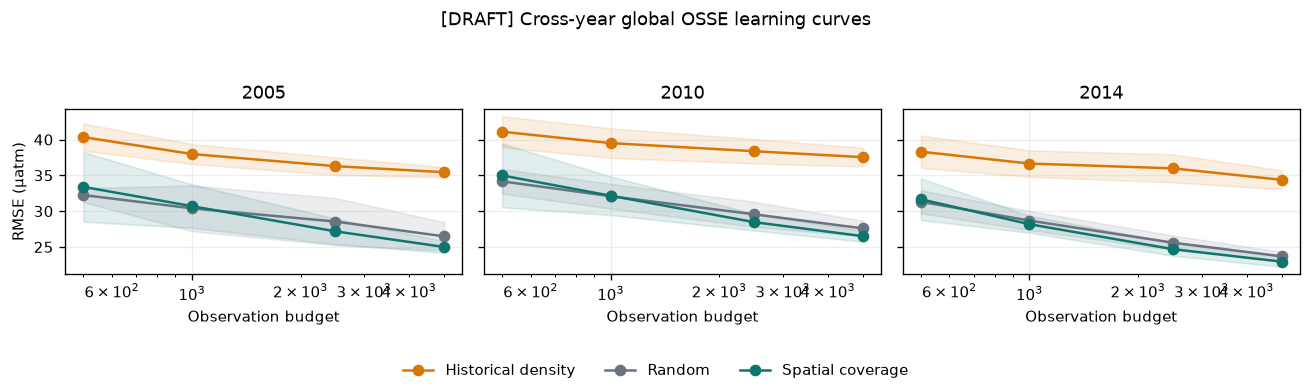

In [5]:
metrics = tables['cross_year_metrics'].query("evaluation_domain == 'all'")
curve = (metrics.groupby(['year', 'strategy', 'budget'], as_index=False)
         .agg(mean_rmse=('rmse', 'mean'), sd_rmse=('rmse', 'std')))
colors = {'random': '#6B7280', 'historical_density': '#D97706',
          'spatial_coverage': '#0F766E'}
labels = {'random': 'Random', 'historical_density': 'Historical density',
          'spatial_coverage': 'Spatial coverage'}
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, (year, year_data) in zip(axes, curve.groupby('year')):
    for strategy, part in year_data.groupby('strategy'):
        ax.plot(part['budget'], part['mean_rmse'], marker='o',
                color=colors[strategy], label=labels[strategy])
        ax.fill_between(part['budget'], part['mean_rmse'] - part['sd_rmse'],
                        part['mean_rmse'] + part['sd_rmse'],
                        color=colors[strategy], alpha=0.12)
    ax.set(title=str(year), xlabel='Observation budget', xscale='log')
    ax.grid(alpha=0.2)
axes[0].set_ylabel('RMSE (µatm)')
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='lower center', ncol=3, frameon=False)
fig.suptitle('[DRAFT] Cross-year global OSSE learning curves')
fig.tight_layout(rect=(0, 0.12, 1, 0.92))
plt.show()

## 4. The non-trivial result: sampling redistributes error

At 5,000 observations, spatial coverage reduces RMSE and p99 absolute error in every tested year, while increasing median absolute error. Thus, the conclusion is not ‘more samples help’: every strategy has the same budget. The result is that sampling geometry trades a small increase in typical error for fewer severe failures. Negative differences favor spatial coverage.

In [6]:
effects = tables['cross_year_effects']
key = effects.query(
    "evaluation_domain == 'all' and budget == 5000 and "
    "comparison == 'spatial_coverage_minus_random' and "
    "metric in ['rmse', 'p99_absolute_error', 'median_absolute_error']"
).copy()
key[['year', 'metric', 'n_seeds', 'mean_difference',
     'seed_bootstrap_low', 'seed_bootstrap_high']].sort_values(['metric', 'year'])

,year,metric,n_seeds,mean_difference,seed_bootstrap_low,seed_bootstrap_high
36,2005,median_absolute_error,20,0.618206,0.524663,0.709110
116,2010,median_absolute_error,20,0.776730,0.655309,0.904204
196,2014,median_absolute_error,20,0.616177,0.508585,0.726481
38,2005,p99_absolute_error,20,-5.701311,-9.844429,-1.951641
118,2010,p99_absolute_error,20,-4.206630,-7.561710,-1.113200
198,2014,p99_absolute_error,20,-4.253115,-6.767142,-1.877132
39,2005,rmse,20,-1.483981,-2.376423,-0.700972
119,2010,rmse,20,-1.088319,-1.704848,-0.506994
199,2014,rmse,20,-0.748521,-1.212835,-0.314813


## 5. Robustness to area weighting

The native-cell-area audit preserves all 12 prespecified cross-year direction checks. This supports the narrower claim that the reported tradeoff is not created by equal weighting within target bins; it does not establish cross-model or real-ocean generality.

In [7]:
audit_filter = (
    "evaluation_domain == 'all' and budget == 5000 and "
    "comparison == 'spatial_coverage_minus_random' and "
    "metric in ['rmse', 'p99_absolute_error', 'median_absolute_error']"
)
equal_bin = tables['cross_year_effects'].query(audit_filter).copy()
area_weighted = tables['regrid_effects'].query(audit_filter).copy()
equal_bin['method'] = 'equal-bin baseline'
area_weighted['method'] = 'native-cell-area audit'
audit = pd.concat([equal_bin, area_weighted], ignore_index=True)
audit[['method', 'year', 'metric', 'mean_difference',
       'seed_bootstrap_low', 'seed_bootstrap_high']].sort_values(
           ['metric', 'year', 'method']
       )

,method,year,metric,mean_difference,seed_bootstrap_low,seed_bootstrap_high
0,equal-bin baseline,2005,median_absolute_error,0.618206,0.524663,0.709110
9,native-cell-area audit,2005,median_absolute_error,0.637497,0.545171,0.728371
3,equal-bin baseline,2010,median_absolute_error,0.776730,0.655309,0.904204
12,native-cell-area audit,2010,median_absolute_error,0.746929,0.623701,0.869463
6,equal-bin baseline,2014,median_absolute_error,0.616177,0.508585,0.726481
15,native-cell-area audit,2014,median_absolute_error,0.593788,0.497382,0.697060
1,equal-bin baseline,2005,p99_absolute_error,-5.701311,-9.844429,-1.951641
10,native-cell-area audit,2005,p99_absolute_error,-5.692825,-9.864447,-1.905328
4,equal-bin baseline,2010,p99_absolute_error,-4.206630,-7.561710,-1.113200
13,native-cell-area audit,2010,p99_absolute_error,-5.024985,-8.265336,-1.935119


## Interpretation boundary and next step

**Supported:** under the locked IPSL-CM6A-LR OSSE, spatial-coverage sampling changes the error distribution consistently across 2005, 2010, and 2014; at the largest budget it reduces RMSE and severe tail error while slightly worsening typical error.  
**Not supported:** universal superiority, causal environmental drivers from SHAP, cross-model robustness, or direct real-ocean performance.  
**Next:** redesign the visual system from the retained tidy CSV tables, then expose the same curated tables through a lightweight interactive website.